<a href="https://colab.research.google.com/github/diegogh1002/Estadistica/blob/main/limpieza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv('csv.csv')
df.head()

,Marca temporal,Dirección de correo electrónico,¿En qué semestre te encuentras actualmente?,¿Qué carrera estudias?,¿Eres alumno regular?,Procedencia (dónde naciste),¿Tienes hermanos?,¿Cuál es la marca de tu teléfono?,Modelo del teléfono,Capacidad del teléfono,Plan o prepago del teléfono,Tiempo que llevas con tu teléfono,Tu teléfono es,Género,¿Trabajas?,Edad,¿Qué teléfono te gustaría tener?
0,3/9/2026 17:30:44,fespinozagarcia0105@gmail.com,Tercero,Ciencia de Datos,NaN,Estado de México,NaN,Honor,Honor x7a,128 GB,Plan,Entre 2 y 3 años,Nuevo,Mujer,Sí,21,NaN
1,3/9/2026 18:02:01,gisellemerino2702@gmail.com,Tercero,Ciencia de Datos,NaN,Estado de México,NaN,Apple,15 pro max,256 GB,Prepago,Entre 6 meses y 1 año,Nuevo,Mujer,No,21,NaN
2,3/9/2026 18:19:25,mildredcaravantes@gmail.com,Primero,Ciencia de Datos,NaN,Estado de México,NaN,Apple,iphone 16 pro max,256 GB,Plan,Entre 1 y 2 años,Nuevo,Mujer,No,20,NaN
3,3/9/2026 18:37:08,garcia.hernandez.edgar.alessandro@gmail.com,Tercero,Ciencia de Datos,NaN,CDMX,NaN,Apple,iPhone 16 Pro Max,256 GB,Plan,Entre 1 y 2 años,Nuevo,Hombre,No,19,NaN
4,3/9/2026 20:56:29,diegobus022@gmail.com,Tercero,Ciencia de Datos,NaN,Otro,NaN,Apple,iPhone 13 Pro max,512 GB,Prepago,Entre 1 y 2 años,Segunda mano,Hombre,No,19,NaN


**ANALISIS EXPLORATORIO EDA**

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 511 entries, 0 to 510
Data columns (total 17 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   Marca temporal                                511 non-null    object
 1   Dirección de correo electrónico               511 non-null    object
 2   ¿En qué semestre te encuentras actualmente?   511 non-null    object
 3   ¿Qué carrera estudias?                        511 non-null    object
 4   ¿Eres alumno regular?                         482 non-null    object
 5   Procedencia  (dónde naciste)                  511 non-null    object
 6   ¿Tienes hermanos?                             482 non-null    object
 7   ¿Cuál es la marca de tu teléfono?             511 non-null    object
 8   Modelo del teléfono                           511 non-null    object
 9   Capacidad del teléfono                        511 non-null    object
 10  Pl

In [68]:
total = len(df)

nulls = df.isnull().sum()
nulls_pct = (nulls / total) * 100

pd.DataFrame({
    "Nulos": nulls,
    "%": nulls_pct
})

,Nulos,%
Marca temporal,0,0.000000
Dirección de correo electrónico,0,0.000000
¿En qué semestre te encuentras actualmente?,0,0.000000
¿Qué carrera estudias?,0,0.000000
¿Eres alumno regular?,29,5.675147
Procedencia (dónde naciste),0,0.000000
¿Tienes hermanos?,29,5.675147
¿Cuál es la marca de tu teléfono?,0,0.000000
Modelo del teléfono,0,0.000000
Capacidad del teléfono,0,0.000000


In [69]:
df_clean = df.copy()

**LIMPIEZA DE DATOS**

In [70]:
# eliminar filas vacías
df_clean = df_clean.dropna(how='all')

# eliminar columna irrelevante
df_clean = df_clean.drop(columns=["Dirección de correo electrónico"], errors='ignore')

In [71]:
# convertir Edad
df_clean["Edad"] = pd.to_numeric(df_clean["Edad"], errors='coerce')

# detectar números en TODAS las columnas automáticamente
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        temp = df_clean[col].astype(str).str.extract(r'(\d+)')
        if temp.notnull().sum().values[0] > len(df_clean) * 0.5:
            df_clean[col + "_num"] = pd.to_numeric(temp[0], errors='coerce')

In [72]:
num_cols = df_clean.select_dtypes(include='number').columns

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

**TRANSFORMACION**

In [73]:
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip().str.upper()

**FEATURE ENGINEERING**

In [74]:
# grupo de edad
if "Edad" in df_clean.columns:
    df_clean["GrupoEdad"] = pd.cut(
        df_clean["Edad"],
        bins=[15,18,21,25,30],
        labels=["16-18","19-21","22-25","26+"]
    )

# alta capacidad
if "Capacidad_num" in df_clean.columns:
    df_clean["AltaCapacidad"] = df_clean["Capacidad_num"] >= 256

**EDA COMPLETO**

In [75]:
num_cols = df_clean.select_dtypes(include='number').columns
cat_cols = df_clean.select_dtypes(exclude='number').columns

In [76]:
stats = pd.DataFrame({
    "Media": df_clean[num_cols].mean(),
    "Mediana": df_clean[num_cols].median(),
    "Moda": df_clean[num_cols].mode().iloc[0],
    "Varianza": df_clean[num_cols].var(),
    "DesvStd": df_clean[num_cols].std(),
    "Min": df_clean[num_cols].min(),
    "Max": df_clean[num_cols].max(),
    "Rango": df_clean[num_cols].max() - df_clean[num_cols].min(),
    "Q1": df_clean[num_cols].quantile(0.25),
    "Q2": df_clean[num_cols].quantile(0.5),
    "Q3": df_clean[num_cols].quantile(0.75)
})

stats

,Media,Mediana,Moda,Varianza,DesvStd,Min,Max,Rango,Q1,Q2,Q3
Edad,2.003914e+01,20.0,20.0,1.837681e+00,1.355611e+00,17.0,2.300000e+01,6.000000e+00,19.0,20.0,21.0
Edad_num,2.003914e+01,20.0,20.0,1.837681e+00,1.355611e+00,17.0,2.300000e+01,6.000000e+00,19.0,20.0,21.0
Capacidad_num,2.026634e+02,128.0,256.0,1.646008e+04,1.282969e+02,1.0,5.120000e+02,5.110000e+02,128.0,128.0,256.0
Marca temporal_num,3.000000e+00,3.0,3.0,0.000000e+00,0.000000e+00,3.0,3.000000e+00,0.000000e+00,3.0,3.0,3.0
Modelo del teléfono_num,6.536668e+07,15.0,15.0,3.603506e+17,6.002921e+08,2.0,5.628486e+09,5.628486e+09,12.0,15.0,25.0
Capacidad del teléfono_num,2.026634e+02,128.0,256.0,1.646008e+04,1.282969e+02,1.0,5.120000e+02,5.110000e+02,128.0,128.0,256.0
Tiempo que llevas con tu teléfono_num,3.487280e+00,3.0,6.0,4.995426e+00,2.235045e+00,1.0,6.000000e+00,5.000000e+00,1.0,3.0,6.0


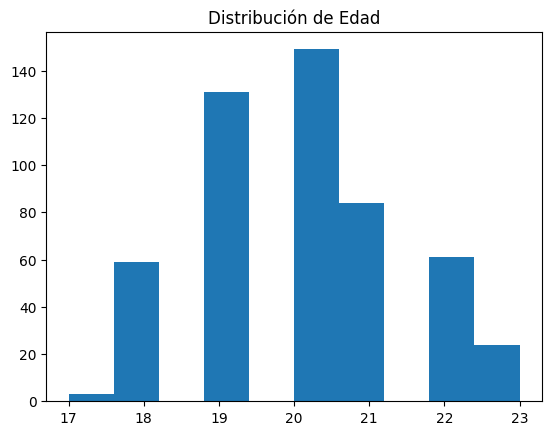

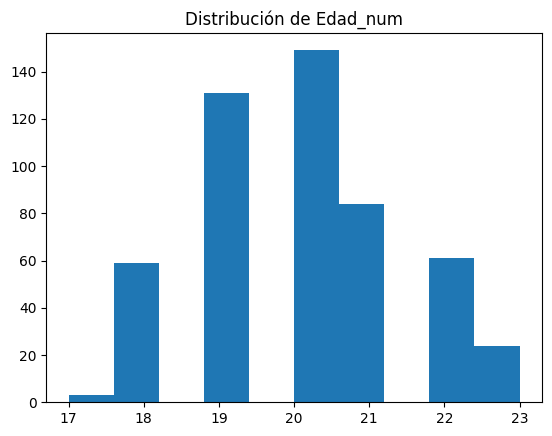

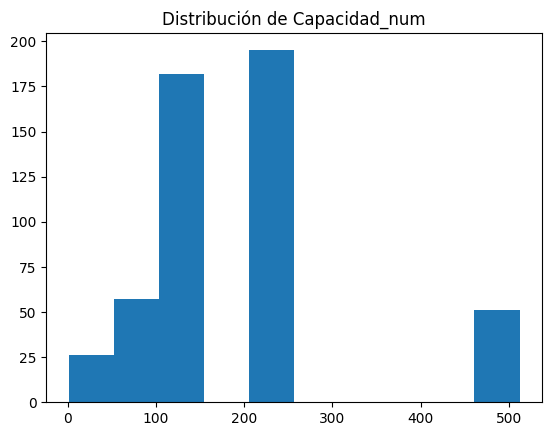

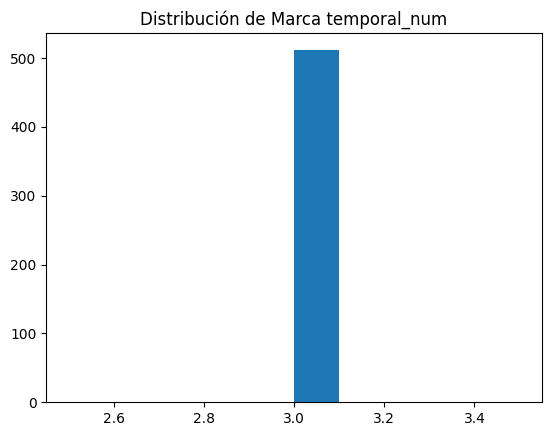

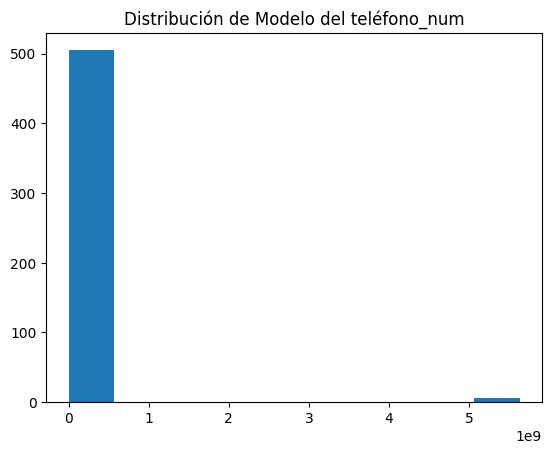

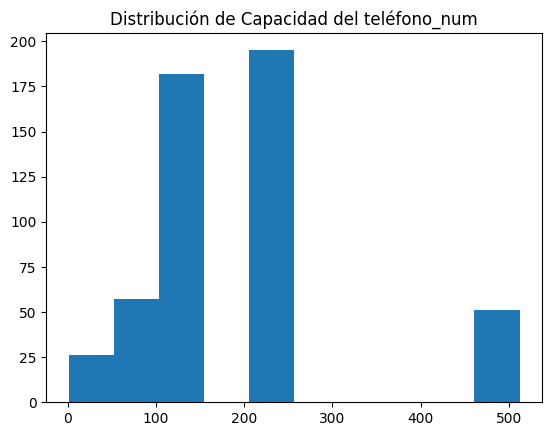

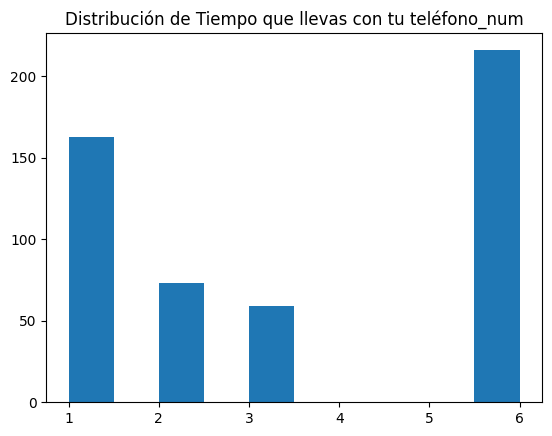

In [77]:
for col in num_cols:
    plt.figure()
    plt.hist(df_clean[col], bins=10)
    plt.title(f"Distribución de {col}")
    plt.show()

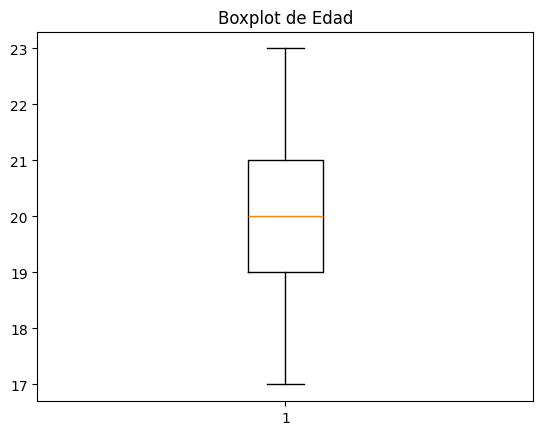

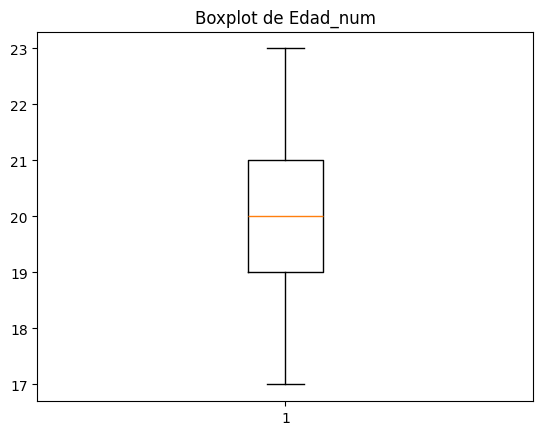

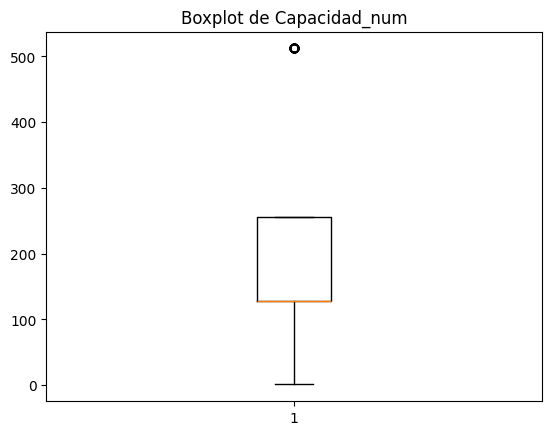

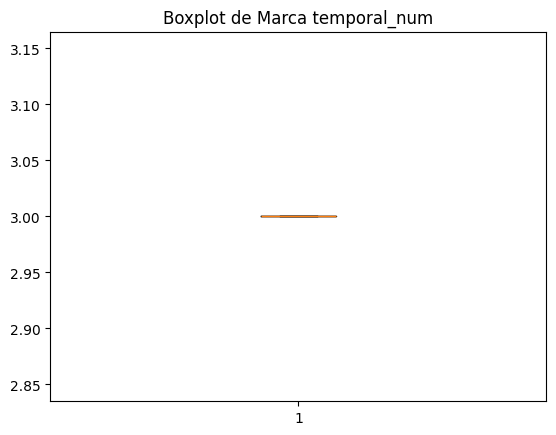

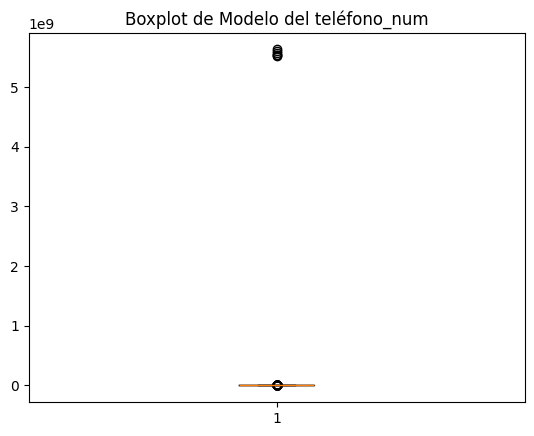

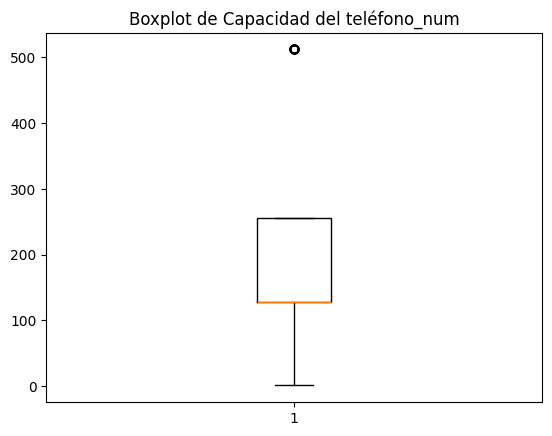

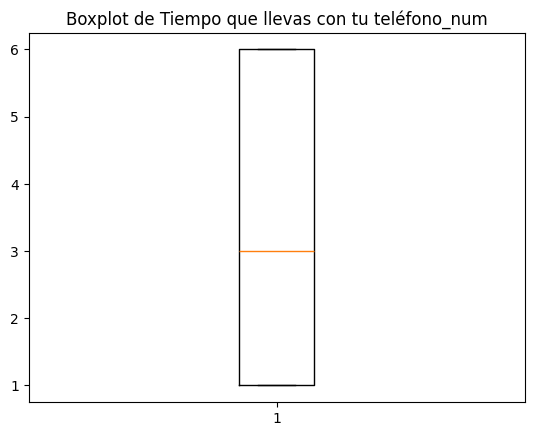

In [78]:
for col in num_cols:
    plt.figure()
    plt.boxplot(df_clean[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/misc.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/misc.py:101: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/misc.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])


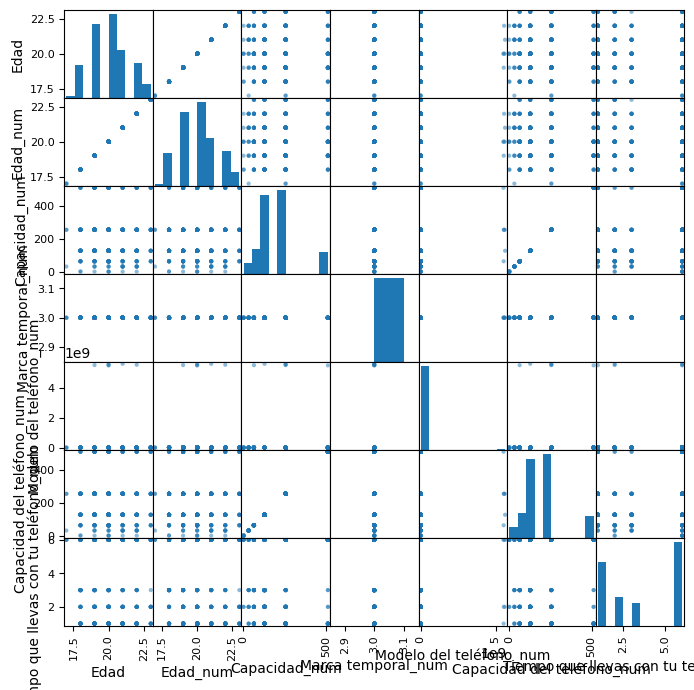

In [79]:
pd.plotting.scatter_matrix(df_clean[num_cols], figsize=(8,8))
plt.show()